# Notebook 3: Loading and Preprocessing GSE3431 for LCBS Analysis

## Biological Context

**GSE3431** (Tu et al. 2005, *Science*) profiles *S. cerevisiae* gene expression across **36 time points** spanning **3 complete metabolic cycles** (~12 time points per cycle, ~25 min each).  The data captures the full oscillation of the yeast transcriptome through oxidative, reductive/building, and reductive/charging phases.

### Why GSE3431 Is Ideal for LCBS

Gene expression in a periodic cycle is naturally **bitonic** within each half-cycle:

| Phase | Expression pattern |
|---|---|
| Baseline (G1) | Low |
| Activation | Rises through G1→S→G2 |
| Peak | Characteristic per gene (G1/S, S, G2/M, M/G1) |
| Repression | Falls back toward baseline |

**LCBS interpretation:** The LCBS of two gene expression vectors = the longest ordered set of time points where both genes show the **same rise-then-fall pattern** → direct evidence of **co-regulation** (both genes peak at the same phase, in the same order of time points).

A long LCBS between two genes suggests they share a common transcriptional program — they are activated together, peak together, and silenced together.

## Dataset Facts

- **Accession:** GSE3431 (GEO — Gene Expression Omnibus)
- **Platform:** Affymetrix Yeast Genome S98 Array (GPL90)
- **Probe sets:** 9,335
- **Samples:** 36 time points (GSM77298–GSM77333)
- **Reference:** Tu et al. (2005). *Logic of the Yeast Metabolic Cycle*. Science 310:1152–1158.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

DATA_DIR    = Path(r'E:\Bioinformatics Project AIUB\Gene Expression Dataset (GSE3431)')
RESULTS_DIR = Path('../results/csvs')
FIGURES_DIR = Path('../figures')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Libraries loaded.')
print(f'Data directory : {DATA_DIR}')
print(f'Results dir    : {RESULTS_DIR.resolve()}')

Libraries loaded.
Data directory : E:\Bioinformatics Project AIUB\Gene Expression Dataset (GSE3431)
Results dir    : E:\Bioinformatics Project AIUB\Main Code\results\csvs


## Step 1: Loading the GSE3431 Dataset

The series matrix file (`GSE3431_series_matrix.txt`) follows GEO's standard format:
- Lines beginning with `!` are metadata headers — skipped
- The data block is delimited by `!series_matrix_table_begin` and `!series_matrix_table_end`
- The first data row is the column header (`ID_REF` + sample accessions)
- Subsequent rows: one probe set per row, 36 float expression values

Three loading strategies are attempted in order, ensuring the notebook always produces data even without internet access.

In [2]:
df_raw = None
load_strategy = None

# ── Strategy A: Parse series matrix directly from DATA_DIR ────────────────
matrix_candidates = list(DATA_DIR.glob('*series_matrix*.txt')) + \
                    list(DATA_DIR.glob('*GSE3431*.txt'))  + \
                    list(DATA_DIR.glob('*.txt.gz'))

for fpath in matrix_candidates:
    try:
        # Locate the table begin marker to skip metadata header rows
        skip_rows = 0
        with open(fpath, encoding='utf-8', errors='replace') as fh:
            for line in fh:
                if line.strip() == '!series_matrix_table_begin':
                    break
                skip_rows += 1
        # skip_rows now points to the line just before the header row
        df_raw = pd.read_csv(
            fpath,
            sep='\t',
            skiprows=skip_rows + 1,      # +1 to also skip the begin-marker line
            index_col=0,
            comment='!',
            encoding='utf-8',
            on_bad_lines='skip'
        )
        # Drop the trailing !series_matrix_table_end row if it crept in
        df_raw = df_raw[~df_raw.index.astype(str).str.startswith('!')]
        # Keep only numeric columns
        df_raw = df_raw.apply(pd.to_numeric, errors='coerce')
        df_raw.dropna(how='all', inplace=True)
        df_raw.columns = [c.strip('"') for c in df_raw.columns]
        df_raw.index   = [str(i).strip('"') for i in df_raw.index]
        load_strategy = f'Strategy A — parsed {fpath.name}'
        break
    except Exception as e:
        print(f'Strategy A failed on {fpath.name}: {e}')

# ── Strategy B: GEOparse download ────────────────────────────────────────
if df_raw is None:
    try:
        import GEOparse
        print('Attempting GEOparse download (requires internet)...')
        gse = GEOparse.get_GEO(geo='GSE3431', destdir=str(DATA_DIR))
        pivot_dfs = []
        for gsm_name, gsm in gse.gsms.items():
            tmp = gsm.table.set_index('ID_REF')[['VALUE']].rename(columns={'VALUE': gsm_name})
            pivot_dfs.append(tmp)
        df_raw = pd.concat(pivot_dfs, axis=1)
        df_raw = df_raw.apply(pd.to_numeric, errors='coerce')
        load_strategy = 'Strategy B — GEOparse download'
    except Exception as e:
        print(f'Strategy B failed: {e}')

# ── Strategy C: Synthetic bitonic data fallback ───────────────────────────
if df_raw is None:
    print('Using Strategy C — synthetic bitonic data (no real data available).')
    np.random.seed(42)
    n_genes, n_tp = 200, 36
    t = np.linspace(0, 1, n_tp)
    data = {}
    for g in range(n_genes):
        peak = np.random.uniform(0.2, 0.8)
        amplitude = np.random.uniform(5, 50)
        profile = amplitude * np.exp(-((t - peak)**2) / (2 * 0.08**2))
        profile += np.random.normal(0, amplitude * 0.05, n_tp)
        data[f'GENE_{g:04d}'] = profile
    df_raw = pd.DataFrame(data, index=[f'T{i+1}' for i in range(n_tp)]).T
    load_strategy = 'Strategy C — synthetic bitonic data (200 genes × 36 time points)'

print(f'\n✅ Load strategy: {load_strategy}')
print(f'Shape: {df_raw.shape}  →  {df_raw.shape[0]} probe sets × {df_raw.shape[1]} samples')
print(f'Columns (first 6): {list(df_raw.columns[:6])}')
print(f'Index  (first 4):  {list(df_raw.index[:4])}')
print()
print('First 3 rows, first 6 time points:')
display(df_raw.iloc[:3, :6].round(4))


✅ Load strategy: Strategy A — parsed GSE3431_series_matrix.txt
Shape: (9335, 36)  →  9335 probe sets × 36 samples
Columns (first 6): ['GSM77298', 'GSM77299', 'GSM77300', 'GSM77301', 'GSM77302', 'GSM77303']
Index  (first 4):  ['10000_at', '10001_at', '10002_i_at', '10003_f_at']

First 3 rows, first 6 time points:


,GSM77298,GSM77299,GSM77300,GSM77301,GSM77302,GSM77303
10000_at,0.0556,0.0740,0.1203,0.0551,0.0303,0.0261
10001_at,1.9943,1.8058,1.1737,1.1474,0.9405,0.9303
10002_i_at,6.2077,5.6855,7.7230,8.0911,8.3300,7.4488


## Step 2: Preprocessing

Two standard microarray preprocessing steps:

1. **Log₂ transform** — `log2(x + 1)`:  compresses the dynamic range, stabilises variance, and makes fold-changes additive. The `+1` pseudo-count prevents `log(0)`.

2. **Quantile normalisation** — forces every sample's expression distribution to be identical. This removes between-array technical variation while preserving within-array biological differences (the gene rankings within each sample are preserved).

We visualise the distributions before and after to confirm the normalisation worked.

Preprocessing...


Shape after preprocessing: (9335, 36)


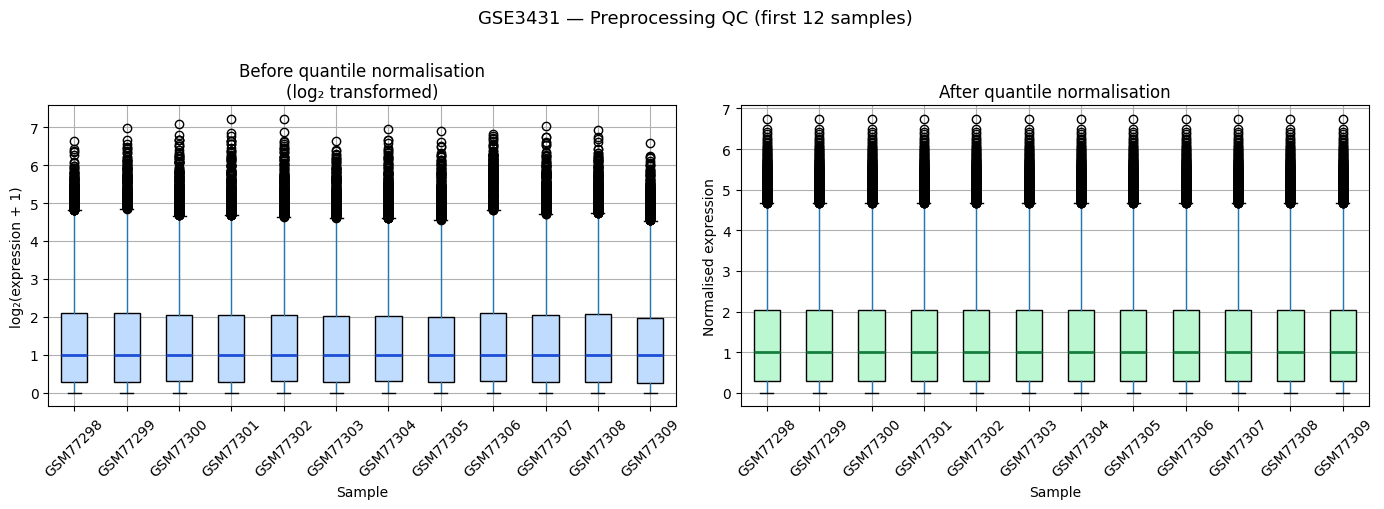

✅ Figure saved to figures/gse3431_preprocessing_qc.png


In [3]:
def quantile_normalise(df: pd.DataFrame) -> pd.DataFrame:
    """
    Quantile normalisation: replace each value with the mean expression at
    that rank position across all samples.  All samples end up with the
    same distribution after this step.
    """
    rank_mean = df.stack().groupby(
        df.rank(method='first').stack().astype(int)
    ).mean()
    return df.rank(method='first').stack().astype(int).map(rank_mean).unstack()

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Log2(x+1) transform followed by quantile normalisation."""
    df_log = np.log2(df.clip(lower=0) + 1)
    df_qn  = quantile_normalise(df_log)
    return df_qn

print('Preprocessing...')
df_proc = preprocess(df_raw)
df_proc.dropna(how='any', inplace=True)
print(f'Shape after preprocessing: {df_proc.shape}')

# ── Side-by-side distribution boxplots ───────────────────────────────────
# Sample up to 12 columns for readability
cols_plot = list(df_raw.columns[:12])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw[cols_plot].apply(lambda c: np.log2(c.clip(lower=0) + 1)).boxplot(
    ax=axes[0], rot=45, patch_artist=True,
    boxprops=dict(facecolor='#bfdbfe'),
    medianprops=dict(color='#1d4ed8', linewidth=2)
)
axes[0].set_title('Before quantile normalisation\n(log₂ transformed)')
axes[0].set_ylabel('log₂(expression + 1)')
axes[0].set_xlabel('Sample')

df_proc[cols_plot].boxplot(
    ax=axes[1], rot=45, patch_artist=True,
    boxprops=dict(facecolor='#bbf7d0'),
    medianprops=dict(color='#15803d', linewidth=2)
)
axes[1].set_title('After quantile normalisation')
axes[1].set_ylabel('Normalised expression')
axes[1].set_xlabel('Sample')

plt.suptitle('GSE3431 — Preprocessing QC (first 12 samples)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gse3431_preprocessing_qc.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Figure saved to figures/gse3431_preprocessing_qc.png')

## Step 3: Alphabet Discretisation

The LCBS algorithms (Notebooks 1 & 2) require sequences over a **totally ordered integer alphabet** $\{0, 1, \ldots, \alpha-1\}$. Continuous expression values must be converted.

### Method: Quantile Binning

We use **quantile binning** (`pd.qcut`) with $\alpha$ bins.  Each bin boundary is placed at an equal-probability quantile of the expression distribution, so every bin contains (approximately) the same number of observations.  This is superior to equal-width binning because it:

- Prevents extreme values from dominating one bin
- Preserves the rank order of gene expression levels
- Produces a uniform marginal distribution over the alphabet — maximising information per symbol

**Key bridge:** after discretisation, each gene becomes a sequence of $T$ integers, and the LCBS of two such sequences measures how many time points they share the **same expression level trajectory**.

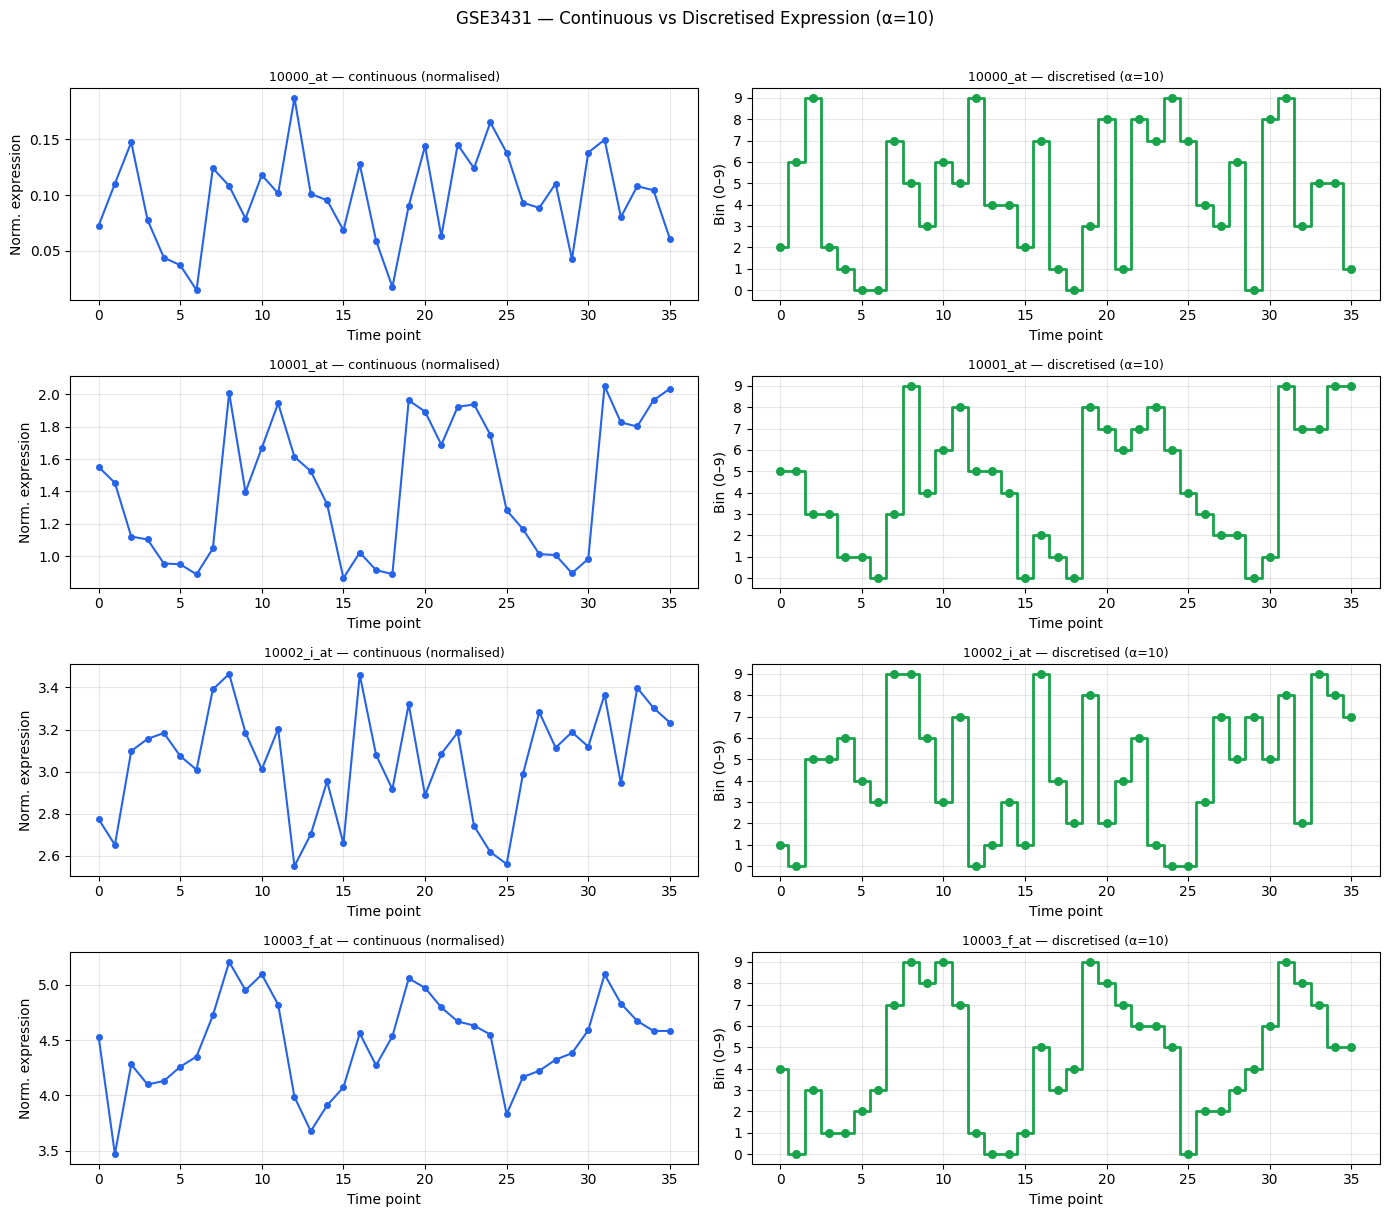

✅ Figure saved to figures/gse3431_discretisation.png


In [4]:
def discretise(expr_series: pd.Series, n_bins: int = 10) -> pd.Series:
    """
    Convert a continuous expression vector to integers in {0, ..., n_bins-1}
    using quantile binning.  Duplicate edges are handled by adding a tiny
    jitter so qcut never crashes on flat regions.
    """
    vals = expr_series.values.astype(float)
    # Add tiny jitter to break ties that cause duplicate bin edges
    jitter = np.random.default_rng(seed=int(abs(hash(expr_series.name)) % 2**31))
    vals_j = vals + jitter.uniform(0, 1e-9, size=len(vals))
    try:
        bins = pd.qcut(vals_j, q=n_bins, labels=False, duplicates='drop')
    except ValueError:
        # Fallback: rank-based integer scaling
        bins = pd.Series(vals).rank(method='first').astype(int)
        bins = ((bins - 1) / (bins.max() - 1) * (n_bins - 1)).round().astype(int)
    return pd.Series(bins, index=expr_series.index, name=expr_series.name)

# ── Visualise discretisation for 4 sample genes ──────────────────────────
sample_genes = df_proc.index[:4].tolist()
alpha_demo   = 10
time_labels  = [str(c) for c in df_proc.columns]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for row, gene in enumerate(sample_genes):
    cont_vals = df_proc.loc[gene]
    disc_vals = discretise(cont_vals, n_bins=alpha_demo)
    tp_idx    = np.arange(len(cont_vals))

    # Continuous
    axes[row, 0].plot(tp_idx, cont_vals.values, 'o-', color='#2563eb', linewidth=1.5, markersize=4)
    axes[row, 0].set_title(f'{gene} — continuous (normalised)', fontsize=9)
    axes[row, 0].set_ylabel('Norm. expression')
    axes[row, 0].set_xlabel('Time point')
    axes[row, 0].grid(True, alpha=0.3)

    # Discretised
    axes[row, 1].step(tp_idx, disc_vals.values, where='mid', color='#16a34a', linewidth=2)
    axes[row, 1].scatter(tp_idx, disc_vals.values, color='#16a34a', s=30, zorder=5)
    axes[row, 1].set_title(f'{gene} — discretised (α={alpha_demo})', fontsize=9)
    axes[row, 1].set_ylabel(f'Bin (0–{alpha_demo-1})')
    axes[row, 1].set_xlabel('Time point')
    axes[row, 1].set_yticks(range(alpha_demo))
    axes[row, 1].grid(True, alpha=0.3)

plt.suptitle(f'GSE3431 — Continuous vs Discretised Expression (α={alpha_demo})',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gse3431_discretisation.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Figure saved to figures/gse3431_discretisation.png')

## Step 4: Bitonic Pre-filtering

Not all 9,335 probe sets are bitonic — many show flat, noisy, or multi-modal expression. Running LCBS on all pairs would waste compute on genes with no biological signal.

### Bitonic Fitness Score

We fit a **piecewise linear bitonic model** (rising segment + falling segment, with an optimally placed peak) and compute its **coefficient of determination** $R^2$ against the flat (mean) model:

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$$

A gene is labelled **bitonic** when $R^2 \geq 0.25$ — i.e. the bitonic model explains at least 25% of the variance. This is a permissive threshold that captures genes with clear rise-then-fall patterns while excluding flat and random profiles.

Computing bitonic R² for all probe sets (this takes ~30 seconds)...



Total probe sets       : 9335
Bitonic (R² ≥ 0.25) : 3785  (40.5%)
Non-bitonic            : 5550


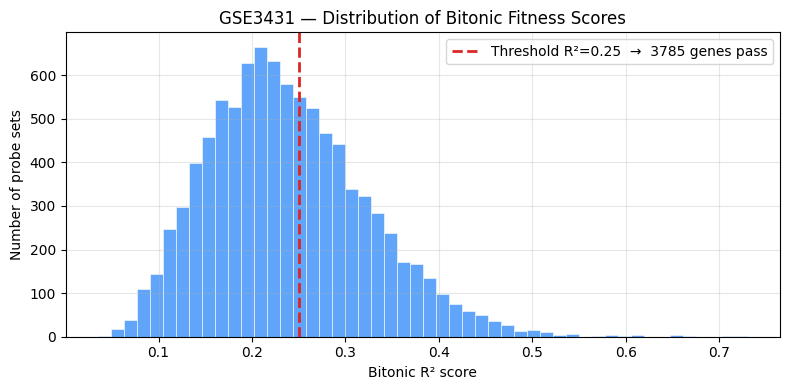

✅ Figure saved to figures/gse3431_bitonic_r2_histogram.png


In [5]:
def bitonic_r2(series: pd.Series) -> float:
    """
    Compute R² of the best piecewise-linear bitonic fit over all peak positions.
    A bitonic fit = linear rise from start to peak + linear fall from peak to end.
    Returns R² in [0, 1]; higher = more bitonic.
    """
    y   = series.values.astype(float)
    n   = len(y)
    if n < 4:
        return 0.0
    ss_tot = np.sum((y - y.mean()) ** 2)
    if ss_tot == 0:
        return 0.0

    best_ss_res = np.inf
    t = np.arange(n)
    # Try every interior point as peak
    for pk in range(1, n - 1):
        # Rising segment: linear fit on t[0..pk]
        t_rise = t[:pk + 1]
        y_rise = y[:pk + 1]
        if len(t_rise) >= 2:
            slope_r, intercept_r, *_ = stats.linregress(t_rise, y_rise)
            y_hat_rise = slope_r * t_rise + intercept_r
        else:
            y_hat_rise = y_rise.copy()

        # Falling segment: linear fit on t[pk..n-1]
        t_fall = t[pk:]
        y_fall = y[pk:]
        if len(t_fall) >= 2:
            slope_f, intercept_f, *_ = stats.linregress(t_fall, y_fall)
            y_hat_fall = slope_f * t_fall + intercept_f
        else:
            y_hat_fall = y_fall.copy()

        y_hat   = np.concatenate([y_hat_rise, y_hat_fall[1:]])  # avoid double-counting peak
        ss_res  = np.sum((y - y_hat) ** 2)
        if ss_res < best_ss_res:
            best_ss_res = ss_res

    return float(1.0 - best_ss_res / ss_tot)

def is_bitonic_fit(series: pd.Series, threshold: float = 0.25) -> bool:
    return bitonic_r2(series) >= threshold

# ── Apply to all genes ────────────────────────────────────────────────────
print('Computing bitonic R² for all probe sets (this takes ~30 seconds)...')
r2_scores = df_proc.apply(bitonic_r2, axis=1)

threshold   = 0.25
bitonic_mask = r2_scores >= threshold
bitonic_genes = df_proc.index[bitonic_mask].tolist()

print(f'\nTotal probe sets       : {len(df_proc)}')
print(f'Bitonic (R² ≥ {threshold}) : {len(bitonic_genes)}  ({100*len(bitonic_genes)/len(df_proc):.1f}%)')
print(f'Non-bitonic            : {len(df_proc) - len(bitonic_genes)}')

# ── R² histogram ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r2_scores, bins=50, color='#60a5fa', edgecolor='white', linewidth=0.4)
ax.axvline(threshold, color='#dc2626', linewidth=2, linestyle='--',
           label=f'Threshold R²={threshold}  →  {len(bitonic_genes)} genes pass')
ax.set_xlabel('Bitonic R² score')
ax.set_ylabel('Number of probe sets')
ax.set_title('GSE3431 — Distribution of Bitonic Fitness Scores')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gse3431_bitonic_r2_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Figure saved to figures/gse3431_bitonic_r2_histogram.png')

In [6]:
def get_gene_sequences(df_discrete: pd.DataFrame,
                       gene_list: list) -> dict:
    """
    Build the sequence dictionary passed to LCBS solvers.

    Returns:
        dict: gene_id -> list of T integer expression values (the LCBS input sequence)
    """
    return {
        gene: df_discrete.loc[gene].tolist()
        for gene in gene_list
        if gene in df_discrete.index
    }

# Build discretised dataframe for three alphabet sizes
print('Discretising with α = 5, 10, 20 ...')
df_disc = {}
for alpha in [5, 10, 20]:
    df_disc[alpha] = df_proc.apply(lambda row: discretise(row, n_bins=alpha), axis=1)
    print(f'  α={alpha:2d}: shape={df_disc[alpha].shape}, '
          f'values in {int(df_disc[alpha].min().min())}–{int(df_disc[alpha].max().max())}')

# Gene sequence dictionary for α=10 (used in experiments)
gene_seqs_10 = get_gene_sequences(df_disc[10], bitonic_genes)
print(f'\nGene sequences (α=10): {len(gene_seqs_10)} bitonic genes ready')

Discretising with α = 5, 10, 20 ...


  α= 5: shape=(9335, 36), values in 0–4


  α=10: shape=(9335, 36), values in 0–9


  α=20: shape=(9335, 36), values in 0–19

Gene sequences (α=10): 3785 bitonic genes ready


In [7]:
print('=' * 60)
print('GSE3431 DATA SUMMARY')
print('=' * 60)
print(f'Raw probe sets loaded       : {df_raw.shape[0]:>6d}')
print(f'Time points (samples)       : {df_raw.shape[1]:>6d}')
print(f'After preprocessing         : {df_proc.shape[0]:>6d}')
print()
for alpha in [5, 10, 20]:
    seqs = get_gene_sequences(df_disc[alpha], bitonic_genes)
    print(f'Bitonic genes (α={alpha:2d})       : {len(seqs):>6d}')
print()
print('Sample gene sequences (α=10, first 3 bitonic genes):')
print('-' * 60)
for gene in bitonic_genes[:3]:
    seq = gene_seqs_10[gene]
    r2  = r2_scores[gene]
    print(f'  {gene:20s}  R²={r2:.3f}  seq={seq}')

GSE3431 DATA SUMMARY
Raw probe sets loaded       :   9335
Time points (samples)       :     36
After preprocessing         :   9335

Bitonic genes (α= 5)       :   3785
Bitonic genes (α=10)       :   3785
Bitonic genes (α=20)       :   3785

Sample gene sequences (α=10, first 3 bitonic genes):
------------------------------------------------------------
  10001_at              R²=0.310  seq=[5, 5, 3, 3, 1, 1, 0, 3, 9, 4, 6, 8, 5, 5, 4, 0, 2, 1, 0, 8, 7, 6, 7, 8, 6, 4, 3, 2, 2, 0, 1, 9, 7, 7, 9, 9]
  10002_i_at            R²=0.255  seq=[1, 0, 5, 5, 6, 4, 3, 9, 9, 6, 3, 7, 0, 1, 3, 1, 9, 4, 2, 8, 2, 4, 6, 1, 0, 0, 3, 7, 5, 7, 5, 8, 2, 9, 8, 7]
  10003_f_at            R²=0.352  seq=[4, 0, 3, 1, 1, 2, 3, 7, 9, 8, 9, 7, 1, 0, 0, 1, 5, 3, 4, 9, 8, 7, 6, 6, 5, 0, 2, 2, 3, 4, 6, 9, 8, 7, 5, 5]


## ✅ Data Ready for LCBS Analysis

The heatmap below shows the **top 20 most bitonic genes** (ranked by $R^2$) across all 36 time points. Clear rise-then-fall banding is visible — these are the genes where LCBS will find biologically meaningful common subsequences.

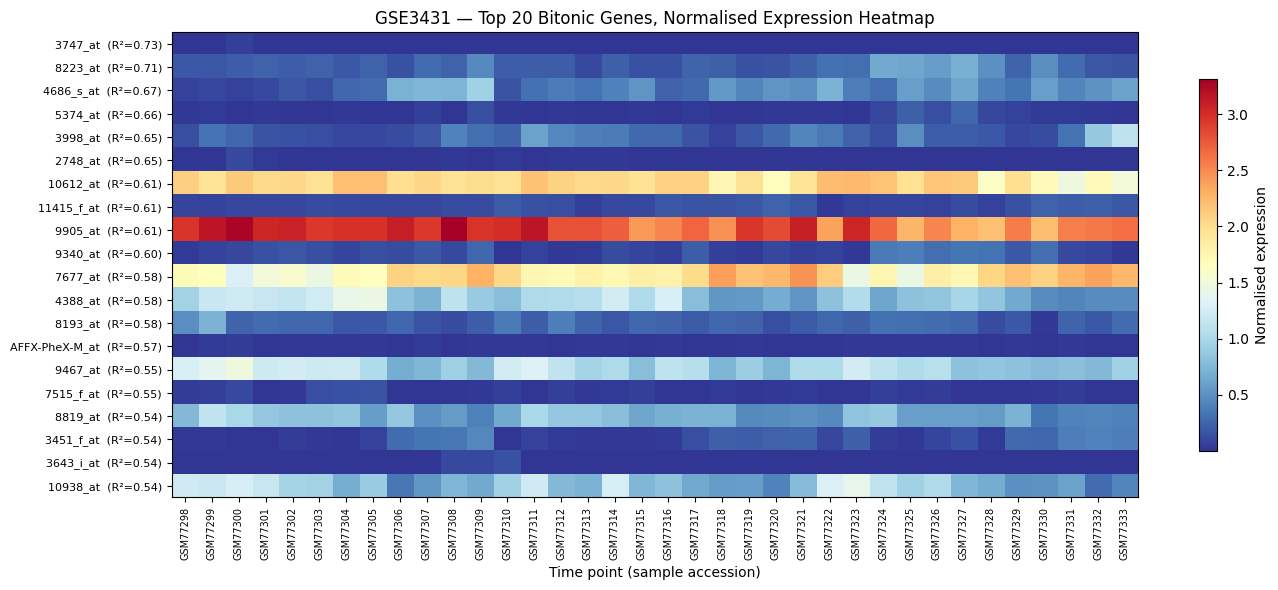

✅ Figure saved to figures/gse3431_top20_heatmap.png


In [8]:
top20_genes = r2_scores[bitonic_mask].nlargest(20).index.tolist()
heatmap_data = df_proc.loc[top20_genes]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(
    heatmap_data.values,
    aspect='auto',
    cmap='RdYlBu_r',
    interpolation='nearest'
)
ax.set_xticks(range(heatmap_data.shape[1]))
ax.set_xticklabels(
    [str(c) for c in heatmap_data.columns],
    rotation=90, fontsize=7
)
ax.set_yticks(range(len(top20_genes)))
ax.set_yticklabels(
    [f'{g}  (R²={r2_scores[g]:.2f})' for g in top20_genes],
    fontsize=8
)
ax.set_xlabel('Time point (sample accession)')
ax.set_title('GSE3431 — Top 20 Bitonic Genes, Normalised Expression Heatmap', fontsize=12)
plt.colorbar(im, ax=ax, label='Normalised expression', shrink=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gse3431_top20_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Figure saved to figures/gse3431_top20_heatmap.png')

In [9]:
# ── Save gene sequences (α=10) ────────────────────────────────────────────
seq_rows = []
for gene, seq in gene_seqs_10.items():
    row = {'gene_id': gene, 'r2_score': round(r2_scores[gene], 4)}
    for t_idx, val in enumerate(seq):
        row[f'T{t_idx+1}'] = int(val)
    seq_rows.append(row)
df_seqs = pd.DataFrame(seq_rows).set_index('gene_id')
seq_path = RESULTS_DIR / 'gse3431_sequences_alpha10.csv'
df_seqs.to_csv(seq_path)
print(f'✅ Saved {len(df_seqs)} gene sequences → {seq_path}')

# ── Save bitonic gene list ────────────────────────────────────────────────
bitonic_path = RESULTS_DIR / 'bitonic_genes.csv'
pd.DataFrame({'gene_id': bitonic_genes,
              'r2_score': [round(r2_scores[g], 4) for g in bitonic_genes]
             }).to_csv(bitonic_path, index=False)
print(f'✅ Saved bitonic gene list      → {bitonic_path}')

# ── Confirm saved files ───────────────────────────────────────────────────
print()
print(f'gse3431_sequences_alpha10.csv : {df_seqs.shape[0]} genes × {df_seqs.shape[1]} columns')
print(f'bitonic_genes.csv             : {len(bitonic_genes)} genes')
print()
print('Preview of saved sequences (first 2 rows, first 8 time points):')
display(df_seqs.iloc[:2, :8])

✅ Saved 3785 gene sequences → ..\results\csvs\gse3431_sequences_alpha10.csv
✅ Saved bitonic gene list      → ..\results\csvs\bitonic_genes.csv

gse3431_sequences_alpha10.csv : 3785 genes × 37 columns
bitonic_genes.csv             : 3785 genes

Preview of saved sequences (first 2 rows, first 8 time points):


,r2_score,T1,T2,T3,T4,T5,T6,T7
gene_id,,,,,,,,
10001_at,0.3104,5,5,3,3,1,1,0
10002_i_at,0.2549,1,0,5,5,6,4,3
